<a href="https://colab.research.google.com/github/jaspreetuppal04/My-Python-practice-programs/blob/main/ML_P5(69).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB, MultinomialNB, GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **Multivariate Bernoulli Naive Bayes**

In [ ]:
# Convert features into binary values
X_train_bernoulli = (X_train > X_train.mean(axis=0)).astype(int)
X_test_bernoulli = (X_test > X_train.mean(axis=0)).astype(int)

bernoulli = BernoulliNB()

bernoulli.fit(X_train_bernoulli, y_train)

y_pred_bernoulli = bernoulli.predict(X_test_bernoulli)

accuracy_bernoulli = accuracy_score(y_test, y_pred_bernoulli)

print("===== Multivariate Bernoulli NB =====")
print("Accuracy:", accuracy_bernoulli)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_bernoulli))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_bernoulli))


===== Multivariate Bernoulli NB =====
Accuracy: 0.8333333333333334

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.44      0.62         9
           2       0.69      1.00      0.81        11

    accuracy                           0.83        30
   macro avg       0.90      0.81      0.81        30
weighted avg       0.89      0.83      0.82        30

Confusion Matrix:
[[10  0  0]
 [ 0  4  5]
 [ 0  0 11]]


# **Multinomial Naive Bayes**

In [ ]:
multinomial = MultinomialNB()

multinomial.fit(X_train, y_train)

y_pred_multinomial = multinomial.predict(X_test)

# Accuracy
accuracy_multinomial = accuracy_score(y_test, y_pred_multinomial)

print("\n===== Multinomial NB =====")
print("Accuracy:", accuracy_multinomial)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_multinomial))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_multinomial))




===== Multinomial NB =====
Accuracy: 0.9

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.75      1.00      0.86         9
           2       1.00      0.73      0.84        11

    accuracy                           0.90        30
   macro avg       0.92      0.91      0.90        30
weighted avg       0.93      0.90      0.90        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  3  8]]


# **Gaussian Naive Bayes**

In [ ]:
gaussian = GaussianNB()

gaussian.fit(X_train, y_train)

y_pred_gaussian = gaussian.predict(X_test)

# Accuracy
accuracy_gaussian = accuracy_score(y_test, y_pred_gaussian)

print("\n===== Gaussian NB =====")
print("Accuracy:", accuracy_gaussian)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gaussian))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gaussian))




===== Gaussian NB =====
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


# **Comparision**

In [ ]:
print("\n===== Comparison of Naive Bayes Models =====")

print("Multivariate Bernoulli NB :", accuracy_bernoulli)
print("Multinomial NB            :", accuracy_multinomial)
print("Gaussian NB               :", accuracy_gaussian)


===== Comparison of Naive Bayes Models =====
Multivariate Bernoulli NB : 0.8333333333333334
Multinomial NB            : 0.9
Gaussian NB               : 1.0


# **Multivariate Bernoulli Naive Bayes**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/voting-records/house-votes-84.data"

columns = [
    "Class",
    "Vote1", "Vote2", "Vote3", "Vote4",
    "Vote5", "Vote6", "Vote7", "Vote8",
    "Vote9", "Vote10", "Vote11", "Vote12",
    "Vote13", "Vote14", "Vote15", "Vote16"
]

data = pd.read_csv(url, names=columns)

data = data.replace("?", np.nan)

for column in columns[1:]:
    data[column] = data[column].map({
        "y": 1,
        "n": 0
    })

# Remove rows containing missing values
data = data.dropna()


# Convert target into binary
data["Class"] = data["Class"].map({
    "democrat": 0,
    "republican": 1
})


# Features and Target
X = data.drop("Class", axis=1)
y = data["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

bernoulli = BernoulliNB()

bernoulli.fit(X_train, y_train)

y_pred = bernoulli.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:")
print(accuracy)


print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Democrat", "Republican"]
))


print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

===== Multivariate Bernoulli Naive Bayes =====

Accuracy:
0.8936170212765957

Classification Report:
              precision    recall  f1-score   support

    Democrat       1.00      0.80      0.89        25
  Republican       0.81      1.00      0.90        22

    accuracy                           0.89        47
   macro avg       0.91      0.90      0.89        47
weighted avg       0.91      0.89      0.89        47

Confusion Matrix:
[[20  5]
 [ 0 22]]


# **Multinomial NB**

Training Data Shape: (11314, 129796)
Testing Data Shape: (7532, 129796)

===== Multinomial Naive Bayes =====

Accuracy:
0.8023101433882103

Accuracy Percentage:
80.23101433882103 %

Classification Report:
                          precision    recall  f1-score   support

             alt.atheism       0.80      0.81      0.80       319
           comp.graphics       0.65      0.80      0.72       389
 comp.os.ms-windows.misc       0.80      0.04      0.08       394
comp.sys.ibm.pc.hardware       0.55      0.80      0.65       392
   comp.sys.mac.hardware       0.85      0.79      0.82       385
          comp.windows.x       0.69      0.84      0.76       395
            misc.forsale       0.89      0.74      0.81       390
               rec.autos       0.89      0.92      0.91       396
         rec.motorcycles       0.95      0.94      0.95       398
      rec.sport.baseball       0.95      0.92      0.93       397
        rec.sport.hockey       0.92      0.97      0.94       399
  

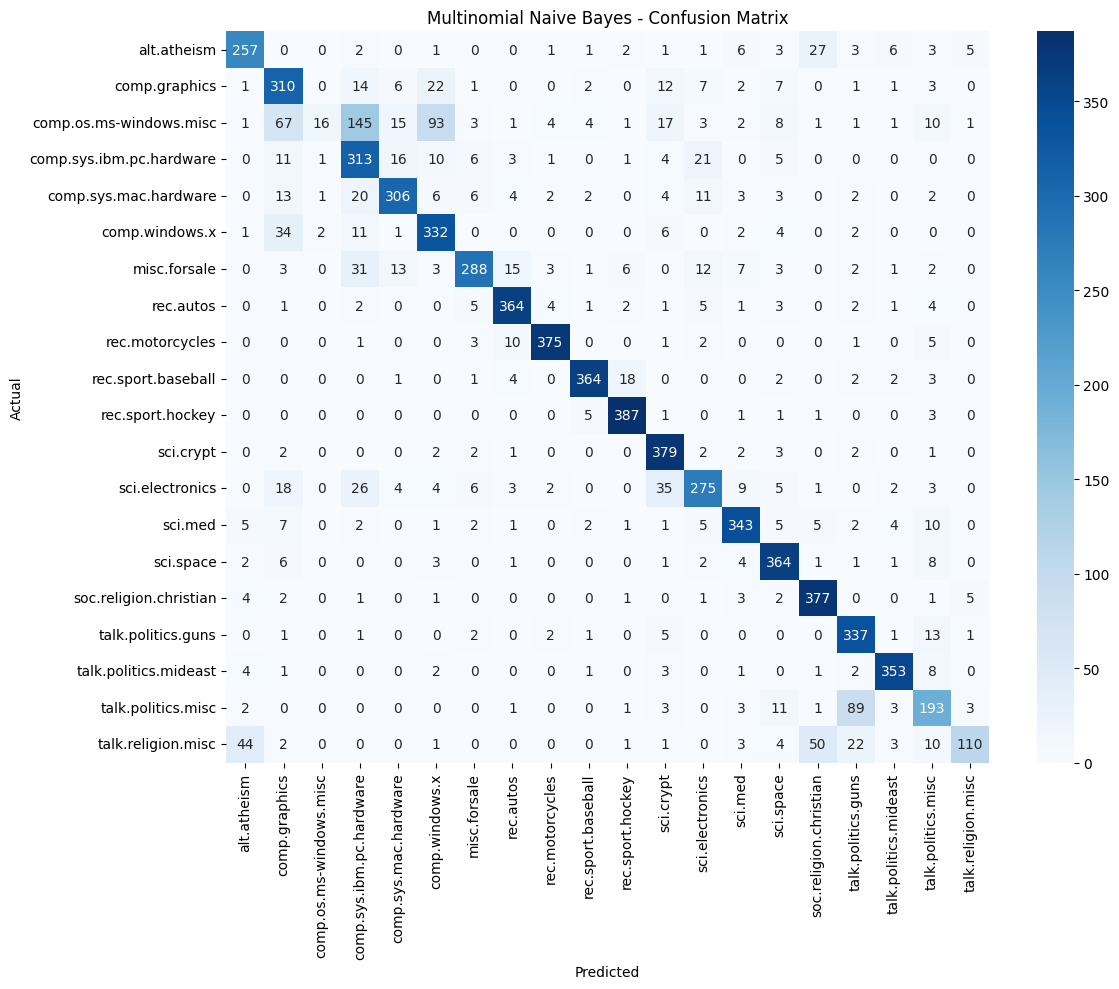

In [ ]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


newsgroups_train = fetch_20newsgroups(
    subset="train",
    shuffle=True,
    random_state=42
)

newsgroups_test = fetch_20newsgroups(
    subset="test",
    shuffle=True,
    random_state=42
)


X_train_text = newsgroups_train.data
X_test_text = newsgroups_test.data

y_train = newsgroups_train.target
y_test = newsgroups_test.target


# Convert text into word-count features
vectorizer = CountVectorizer(
    stop_words="english"
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)


print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

model = MultinomialNB()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n===== Multinomial Naive Bayes =====")

print("\nAccuracy:")
print(accuracy)

print("\nAccuracy Percentage:")
print(accuracy * 100, "%")


print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=newsgroups_test.target_names
    )
)


cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=newsgroups_test.target_names,
    yticklabels=newsgroups_test.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Multinomial Naive Bayes - Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

# **GAUSSIAN NB**

In [ ]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


wine = load_wine()

X = wine.data
y = wine.target


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


model = GaussianNB()


model.fit(X_train, y_train)


y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)

print("===== Gaussian Naive Bayes =====")

print("\nAccuracy:")
print(accuracy)

print("\nAccuracy Percentage:")
print(accuracy * 100, "%")


print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=wine.target_names
    )
)


cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


===== Gaussian Naive Bayes =====

Accuracy:
0.9722222222222222

Accuracy Percentage:
97.22222222222221 %

Classification Report:
              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       1.00      0.93      0.96        14
     class_2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36


Confusion Matrix:
[[12  0  0]
 [ 1 13  0]
 [ 0  0 10]]
